In [2]:
%matplotlib ipympl

In [3]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal, norm

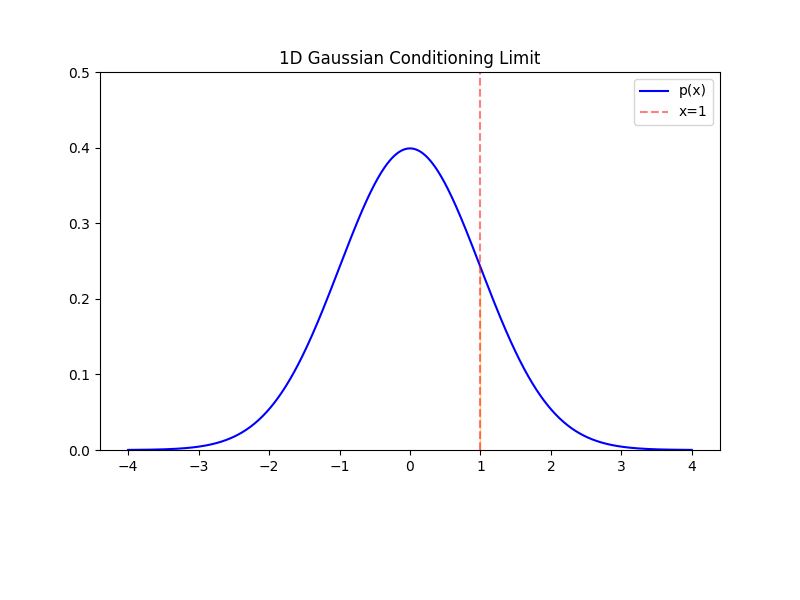

In [4]:
# --- Animation 1: 1D Gaussian ---
fig1, ax1 = plt.subplots(figsize=(8, 6))
x_vals = np.linspace(-4, 4, 1000)
pdf_vals = norm.pdf(x_vals)
ax1.plot(x_vals, pdf_vals, label="p(x)", color="blue")
ax1.axvline(x=1, color="red", linestyle="--", alpha=0.5, label="x=1")

# Rectangle to represent the epsilon width
rect = plt.Rectangle((1, 0), 0, norm.pdf(1), color="orange", alpha=0.5)
ax1.add_patch(rect)

# Equation text area
eq_text = ax1.text(0.5, -0.3, "", transform=ax1.transAxes, ha="center", fontsize=12)
ax1.set_ylim(0, 0.5)
ax1.set_title("1D Gaussian Conditioning Limit")
ax1.legend()
plt.subplots_adjust(bottom=0.25)


def init1():
    rect.set_width(0)
    rect.set_xy((1, 0))
    eq_text.set_text("")
    return rect, eq_text


def update1(frame):
    # Epsilon shrinks from 2.0 to 0.05 over 50 frames
    eps = 2.0 - (1.95 * (frame / 50))
    rect.set_width(eps)
    rect.set_xy((1 - eps / 2, 0))

    # Calculate probability mass approximation
    area = norm.pdf(1) * eps

    # Equation update
    eq_string = (
        r"$\mathbb{E}[Y \mid X = x] = \lim_{\epsilon \to 0} \mathbb{E}[Y \mid x - \frac{\epsilon}{2} < X < x + \frac{\epsilon}{2}]$"
        + "\n"
        + r" $\triangleq p(x)\epsilon$"
    )
    eq_text.set_text(eq_string)
    return rect, eq_text


ani1 = animation.FuncAnimation(fig1, update1, frames=51, init_func=init1, blit=True)

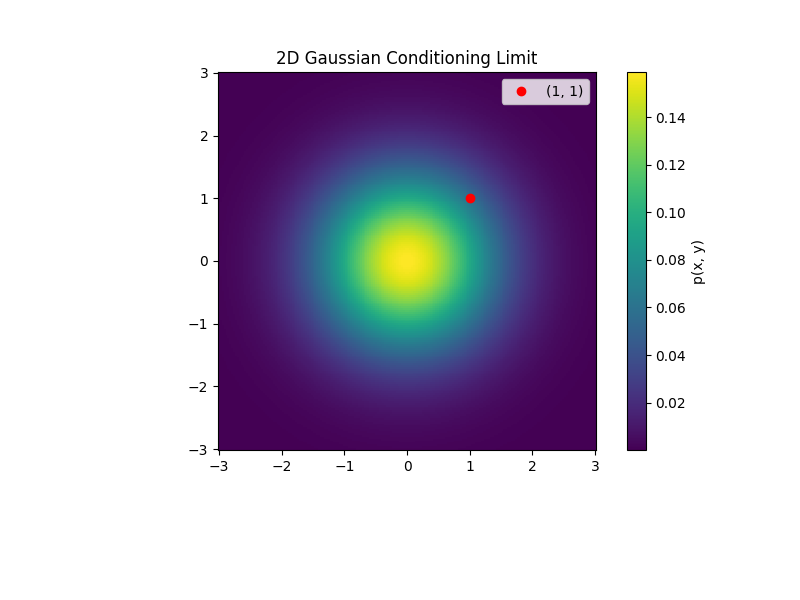

In [5]:
# --- Animation 2: 2D Gaussian ---
fig2, ax2 = plt.subplots(figsize=(8, 6))
X, Y = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
pos = np.dstack((X, Y))
rv = multivariate_normal([0, 0], [[1, 0], [0, 1]])
Z = rv.pdf(pos)

c = ax2.pcolormesh(X, Y, Z, shading="auto", cmap="viridis")
fig2.colorbar(c, ax=ax2, label="p(x, y)")
ax2.plot(1, 1, "ro", label="(1, 1)")

# Square to represent the epsilon width
rect2 = plt.Rectangle((1, 1), 0, 0, color="red", fill=False, lw=2)
ax2.add_patch(rect2)

eq_text2 = ax2.text(0.5, -0.3, "", transform=ax2.transAxes, ha="center", fontsize=12)
ax2.set_title("2D Gaussian Conditioning Limit")
ax2.legend()
ax2.set_aspect("equal")
plt.subplots_adjust(bottom=0.25)


def init2():
    rect2.set_width(0)
    rect2.set_height(0)
    rect2.set_xy((1, 1))
    eq_text2.set_text("")
    return rect2, eq_text2


def update2(frame):
    eps = 2.0 - (1.95 * (frame / 50))
    rect2.set_width(eps)
    rect2.set_height(eps)
    rect2.set_xy((1 - eps / 2, 1 - eps / 2))

    vol = rv.pdf([1, 1]) * (eps**2)

    eq_string2 = (
        r"$\mathbb{E}[Z \mid X = 1, Y = 1] = \lim_{\epsilon \to 0} \mathbb{E}[Z \mid (X,Y) \in [1 -\frac{\epsilon}{2}, 1 + \frac{\epsilon}{2}]^2]$"
        + "\n"
        + r"$\triangleq p(x,y)\epsilon^2$"
    )
    eq_text2.set_text(eq_string2)
    return rect2, eq_text2


ani2 = animation.FuncAnimation(fig2, update2, frames=51, init_func=init2, blit=True)

# Tropical Semiring

$\mathbb{R}_{\min}[\epsilon] = \{a \epsilon^n \mid a \in \mathbb{R}, n\in \mathbb{N}\}$
- $\epsilon^n \otimes \epsilon^m = \epsilon^{n \cdot m}$
- $\epsilon^n \oplus \epsilon^m = \epsilon^{\min(n, m)}$
